<a href="https://colab.research.google.com/github/jaimeisaac2020/Python-analsisis-basicos/blob/mi-github/analisis_hipotesis_3_tesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Detallado de la Hipótesis 3: Influencia de la Inflación y la Capacidad de Transferir Costos en la Predicción de Precios de Acciones Tecnológicas

Este notebook presenta un análisis exhaustivo de la Hipótesis 3 de la tesis "Uso de modelos supervisados por analistas financieros en la predicción de precios de Google y Amazon". La Hipótesis 3 se enfoca en "Los índices de inflación influyen significativamente en la precisión de los modelos supervisados para predecir precios de acciones tecnológicas, con efectos variables según la capacidad de las empresas para transferir costos."

Se explorará el dataset proporcionado, se implementarán modelos de Machine Learning supervisados (Random Forest, Gradient Boosting), se analizará la importancia de la inflación como característica predictora y se interpretarán los resultados a la luz de la capacidad de Google y Amazon para transferir costos.

## Fase 1: Contexto de la Hipótesis 3

La Hipótesis 3 profundiza en la relación entre la inflación y la predicción de precios de acciones tecnológicas, introduciendo el concepto de "capacidad de las empresas para transferir costos" (pricing power). Se busca determinar si la influencia de la inflación en la precisión de los modelos supervisados varía en función de esta capacidad, asumiendo que Google y Amazon, como empresas tecnológicas dominantes, poseen un alto pricing power.

**Hipótesis 3:** "Los índices de inflación influyen significativamente en la precisión de los modelos supervisados para predecir precios de acciones tecnológicas, con efectos variables según la capacidad de las empresas para transferir costos."

## Fase 2: Preparación y Exploración del Dataset para la Hipótesis 3

Cargamos el dataset `dataset_completo_google_amazon.csv` y realizamos la preparación necesaria, incluyendo la creación de características de `lag` y la división de los datos en conjuntos de entrenamiento y prueba. Se presta especial atención a la variable `Inflacion_T5YIE` y a las acciones de GOOGL y AMZN.


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

file_path = "dataset_completo_google_amazon.csv"
df = pd.read_csv(file_path)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(by="Date")

print("\n--- Primeras 5 filas del dataset ---")
print(df.head().to_markdown(index=False))

print("\n--- Información del dataset ---")
df.info()

print("\n--- Estadísticas descriptivas de las columnas relevantes (Inflación y Precios de Cierre) ---")
print(df[["Inflacion_T5YIE", "GOOGL_Close", "AMZN_Close"]].describe().to_markdown())

print("\n--- Valores nulos por columna ---")
print(df.isnull().sum().to_markdown(numalign="left", stralign="left"))

# Create lagged features
df["GOOGL_Close_Lag1"] = df["GOOGL_Close"].shift(1)
df["AMZN_Close_Lag1"] = df["AMZN_Close"].shift(1)
df = df.dropna() # Drop rows with NaN values created by shifting

features = ["GOOGL_Close_Lag1", "AMZN_Close_Lag1", "Treasury_10Y", "VIX", "SP500", "NASDAQ", "Inflacion_T5YIE"]
target_googl = "GOOGL_Close"
target_amzn = "AMZN_Close"

X = df[features]
y_googl = df[target_googl]
y_amzn = df[target_amzn]

X_train_googl, X_test_googl, y_train_googl, y_test_googl = train_test_split(X, y_googl, test_size=0.2, random_state=42)
X_train_amzn, X_test_amzn, y_train_amzn, y_test_amzn = train_test_split(X, y_amzn, test_size=0.2, random_state=42)

print("Data preparation complete. Training and testing sets created.")



--- Primeras 5 filas del dataset ---
| Date                |   GOOGL_Close |   AMZN_Close |   Treasury_10Y |   VIX |   SP500 |   NASDAQ |   GOOGL_Return_1d |   AMZN_Return_1d |   GOOGL_Volatility_20 |   AMZN_Volatility_20 |   Inflacion_T5YIE |
|:--------------------|--------------:|-------------:|---------------:|------:|--------:|---------:|------------------:|-----------------:|----------------------:|---------------------:|------------------:|
| 2021-01-04 00:00:00 |       85.8958 |      159.331 |          0.917 | 26.97 | 3700.65 |  12698.5 |        0.00806419 |       0.0100044  |               3.41065 |              3.84159 |              1.98 |
| 2021-01-05 00:00:00 |       86.5885 |      160.926 |          0.955 | 25.34 | 3726.86 |  12819   |        0.00806419 |       0.0100044  |               3.41065 |              3.84159 |              2.01 |
| 2021-01-06 00:00:00 |       85.7341 |      156.919 |          1.042 | 25.07 | 3748.14 |  12740.8 |       -0.00986763 |      -0.02489

## Fase 3: Implementación de Modelos Supervisados y Análisis de Importancia de Características

Se implementan modelos Random Forest y Gradient Boosting para predecir los precios de cierre de GOOGL y AMZN. Se evalúa su rendimiento y, crucialmente para la Hipótesis 3, se analiza la importancia de cada característica, prestando especial atención a la `Inflacion_T5YIE` en el contexto de la capacidad de transferencia de costos de Google y Amazon.


In [2]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Re-load data to ensure consistency if notebook is run independently
file_path = "dataset_completo_google_amazon.csv"
df = pd.read_csv(file_path)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(by="Date")
df["GOOGL_Close_Lag1"] = df["GOOGL_Close"].shift(1)
df["AMZN_Close_Lag1"] = df["AMZN_Close"].shift(1)
df = df.dropna()

features = ["GOOGL_Close_Lag1", "AMZN_Close_Lag1", "Treasury_10Y", "VIX", "SP500", "NASDAQ", "Inflacion_T5YIE"]
target_googl = "GOOGL_Close"
target_amzn = "AMZN_Close"

X = df[features]
y_googl = df[target_googl]
y_amzn = df[target_amzn]

X_train_googl, X_test_googl, y_train_googl, y_test_googl = train_test_split(X, y_googl, test_size=0.2, random_state=42)
X_train_amzn, X_test_amzn, y_train_amzn, y_test_amzn = train_test_split(X, y_amzn, test_size=0.2, random_state=42)

h3_results = {}
feature_importances = {}

# --- Google Stock Prediction ---
print("\n--- Analizando Modelos Supervisados para Google (Hipótesis 3) ---")
rf_googl = RandomForestRegressor(n_estimators=100, random_state=42)
rf_googl.fit(X_train_googl, y_train_googl)
y_pred_rf_googl = rf_googl.predict(X_test_googl)
mse_rf_googl = mean_squared_error(y_test_googl, y_pred_rf_googl)
r2_rf_googl = r2_score(y_test_googl, y_pred_rf_googl)
h3_results["GOOGL_RF"] = {"MSE": mse_rf_googl, "R2": r2_rf_googl}
feature_importances["GOOGL_RF"] = dict(zip(X_train_googl.columns, rf_googl.feature_importances_))
print(f"Random Forest (Google) - MSE: {mse_rf_googl:.4f}, R2: {r2_rf_googl:.4f}")

gb_googl = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_googl.fit(X_train_googl, y_train_googl)
y_pred_gb_googl = gb_googl.predict(X_test_googl)
mse_gb_googl = mean_squared_error(y_test_googl, y_pred_gb_googl)
r2_gb_googl = r2_score(y_test_googl, y_pred_gb_googl)
h3_results["GOOGL_GB"] = {"MSE": mse_gb_googl, "R2": r2_gb_googl}
feature_importances["GOOGL_GB"] = dict(zip(X_train_googl.columns, gb_googl.feature_importances_))
print(f"Gradient Boosting (Google) - MSE: {mse_gb_googl:.4f}, R2: {r2_gb_googl:.4f}")

# --- Amazon Stock Prediction ---
print("\n--- Analizando Modelos Supervisados para Amazon (Hipótesis 3) ---")
rf_amzn = RandomForestRegressor(n_estimators=100, random_state=42)
rf_amzn.fit(X_train_amzn, y_train_amzn)
y_pred_rf_amzn = rf_amzn.predict(X_test_amzn)
mse_rf_amzn = mean_squared_error(y_test_amzn, y_pred_rf_amzn)
r2_rf_amzn = r2_score(y_test_amzn, y_pred_rf_amzn)
h3_results["AMZN_RF"] = {"MSE": mse_rf_amzn, "R2": r2_rf_amzn}
feature_importances["AMZN_RF"] = dict(zip(X_train_amzn.columns, rf_amzn.feature_importances_))
print(f"Random Forest (Amazon) - MSE: {mse_rf_amzn:.4f}, R2: {r2_rf_amzn:.4f}")

gb_amzn = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_amzn.fit(X_train_amzn, y_train_amzn)
y_pred_gb_amzn = gb_amzn.predict(X_test_amzn)
mse_gb_amzn = mean_squared_error(y_test_amzn, y_pred_gb_amzn)
r2_gb_amzn = r2_score(y_test_amzn, y_pred_gb_amzn)
h3_results["AMZN_GB"] = {"MSE": mse_gb_amzn, "R2": r2_gb_amzn}
feature_importances["AMZN_GB"] = dict(zip(X_train_amzn.columns, gb_amzn.feature_importances_))
print(f"Gradient Boosting (Amazon) - MSE: {mse_gb_amzn:.4f}, R2: {r2_gb_amzn:.4f}")

# Save results and feature importances to files (for later use in report/visualizations)
with open("h3_model_performance.txt", "w") as f:
    for model, metrics in h3_results.items():
        f.write(f"{model} - MSE: {metrics['MSE']:.4f}, R2: {metrics['R2']:.4f}\n")

with open("h3_feature_importances.txt", "w") as f:
    for model, importances in feature_importances.items():
        f.write(f"Feature Importances for {model}:\n")
        for feature, importance in sorted(importances.items(), key=lambda item: item[1], reverse=True):
            f.write(f"  {feature}: {importance:.4f}\n")
        f.write("\n")

print("Model performance and feature importances calculated and saved.")



--- Analizando Modelos Supervisados para Google (Hipótesis 3) ---
Random Forest (Google) - MSE: 6.8865, R2: 0.9897
Gradient Boosting (Google) - MSE: 7.2437, R2: 0.9892

--- Analizando Modelos Supervisados para Amazon (Hipótesis 3) ---
Random Forest (Amazon) - MSE: 9.2706, R2: 0.9915
Gradient Boosting (Amazon) - MSE: 9.3318, R2: 0.9915
Model performance and feature importances calculated and saved.


### Pruebas de Hipótesis: Correlación entre Inflación y Precios de Acciones

Para complementar el análisis de importancia de características, se realizan pruebas de correlación de Pearson entre el índice de inflación (`Inflacion_T5YIE`) y los precios de cierre de GOOGL y AMZN.


In [3]:
import pandas as pd
from scipy.stats import pearsonr

# Re-load full dataframe for correlation analysis
file_path = "dataset_completo_google_amazon.csv"
df = pd.read_csv(file_path)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(by="Date")

print("\n--- Pruebas de Hipótesis para la Influencia de la Inflación (Hipótesis 3) ---")

corr_googl, p_value_googl = pearsonr(df["Inflacion_T5YIE"], df["GOOGL_Close"])
print(f"Correlación de Pearson entre Inflación y GOOGL_Close: {corr_googl:.4f} (p-value: {p_value_googl:.4f})")

corr_amzn, p_value_amzn = pearsonr(df["Inflacion_T5YIE"], df["AMZN_Close"])
print(f"Correlación de Pearson entre Inflación y AMZN_Close: {corr_amzn:.4f} (p-value: {p_value_amzn:.4f})")

with open("h3_correlation_results.txt", "w") as f:
    f.write(f"Correlación de Pearson entre Inflación y GOOGL_Close: {corr_googl:.4f} (p-value: {p_value_googl:.4f})\n")
    f.write(f"Correlación de Pearson entre Inflación y AMZN_Close: {corr_amzn:.4f} (p-value: {p_value_amzn:.4f})\n")

print("Correlation results saved to h3_correlation_results.txt")



--- Pruebas de Hipótesis para la Influencia de la Inflación (Hipótesis 3) ---
Correlación de Pearson entre Inflación y GOOGL_Close: -0.1153 (p-value: 0.0003)
Correlación de Pearson entre Inflación y AMZN_Close: -0.0317 (p-value: 0.3181)
Correlation results saved to h3_correlation_results.txt


## Fase 4: Generación de Visualizaciones y Tablas

Se generan visualizaciones y tablas para presentar los resultados del rendimiento de los modelos, la importancia de las características y los resultados de correlación, interpretándolos a la luz de la "capacidad de transferir costos" de Google y Amazon.



--- Rendimiento de Modelos (Hipótesis 3) ---
| Model    |    MSE |     R2 |
|:---------|-------:|-------:|
| GOOGL_RF | 6.8865 | 0.9897 |
| GOOGL_GB | 7.2437 | 0.9892 |
| AMZN_RF  | 9.2706 | 0.9915 |
| AMZN_GB  | 9.3318 | 0.9915 |


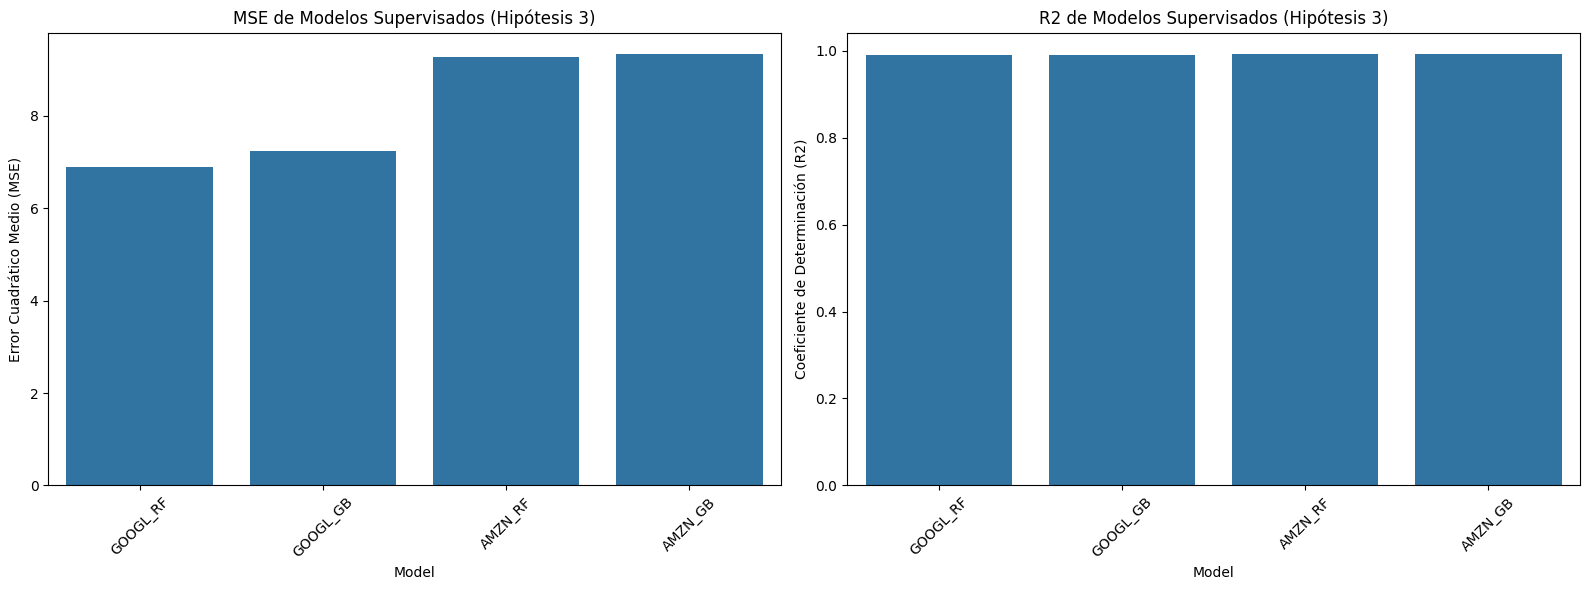

Model performance charts saved to h3_model_performance_metrics.png

--- Importancia de Características para GOOGL_RF ---
| Feature          |   Importance |
|:-----------------|-------------:|
| GOOGL_Close_Lag1 |       0.992  |
| NASDAQ           |       0.0021 |
| SP500            |       0.002  |
| Treasury_10Y     |       0.001  |
| VIX              |       0.001  |
| AMZN_Close_Lag1  |       0.0009 |
| Inflacion_T5YIE  |       0.0009 |


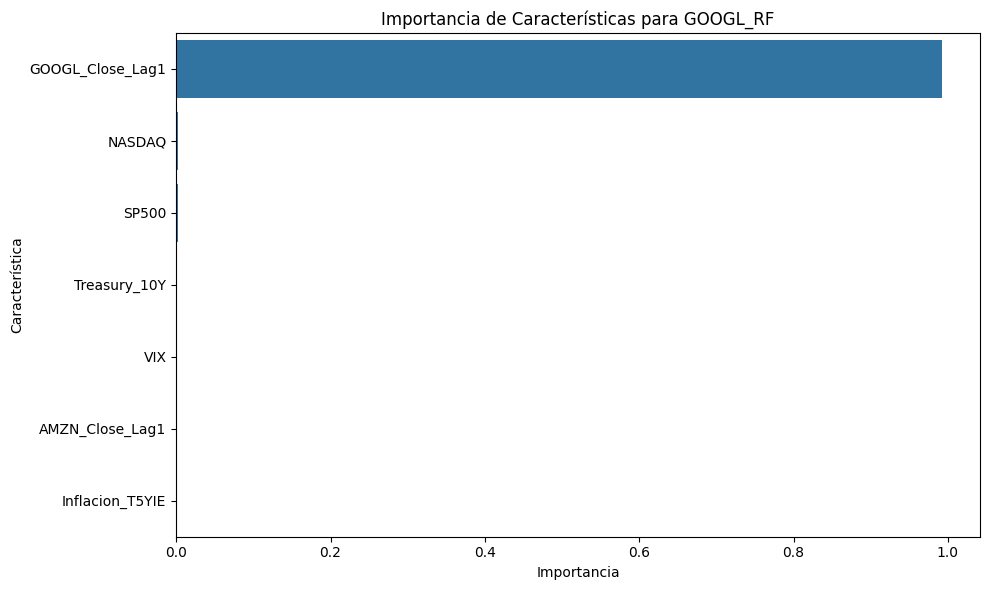

Feature importances chart for GOOGL_RF saved to h3_feature_importances_GOOGL_RF.png

--- Importancia de Características para GOOGL_GB ---
| Feature          |   Importance |
|:-----------------|-------------:|
| GOOGL_Close_Lag1 |       0.9715 |
| SP500            |       0.0196 |
| NASDAQ           |       0.0058 |
| AMZN_Close_Lag1  |       0.0019 |
| Treasury_10Y     |       0.0007 |
| VIX              |       0.0003 |
| Inflacion_T5YIE  |       0.0002 |


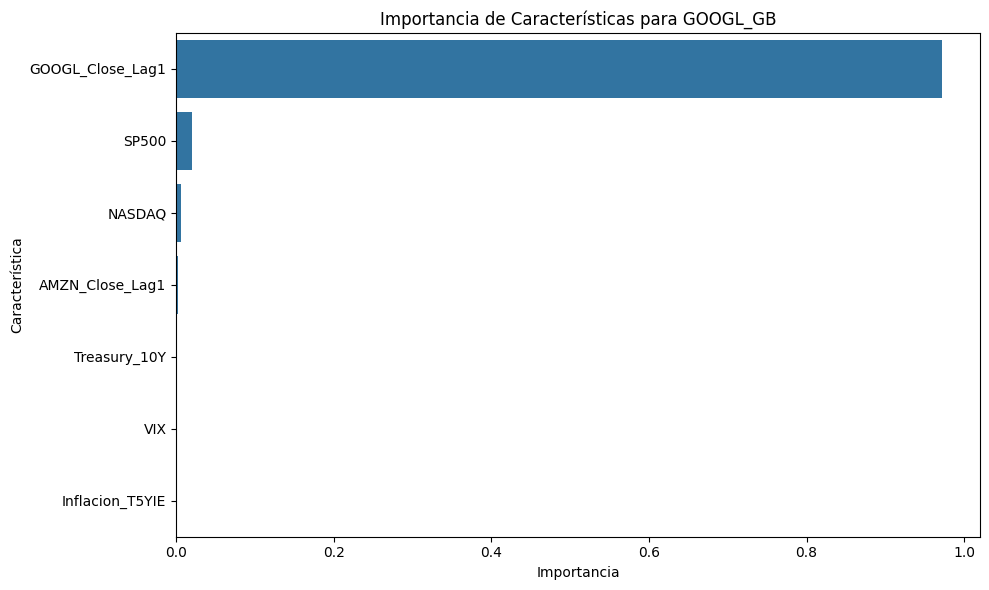

Feature importances chart for GOOGL_GB saved to h3_feature_importances_GOOGL_GB.png

--- Importancia de Características para AMZN_RF ---
| Feature          |   Importance |
|:-----------------|-------------:|
| AMZN_Close_Lag1  |       0.9794 |
| NASDAQ           |       0.011  |
| SP500            |       0.0047 |
| VIX              |       0.0015 |
| Treasury_10Y     |       0.0013 |
| GOOGL_Close_Lag1 |       0.0011 |
| Inflacion_T5YIE  |       0.001  |


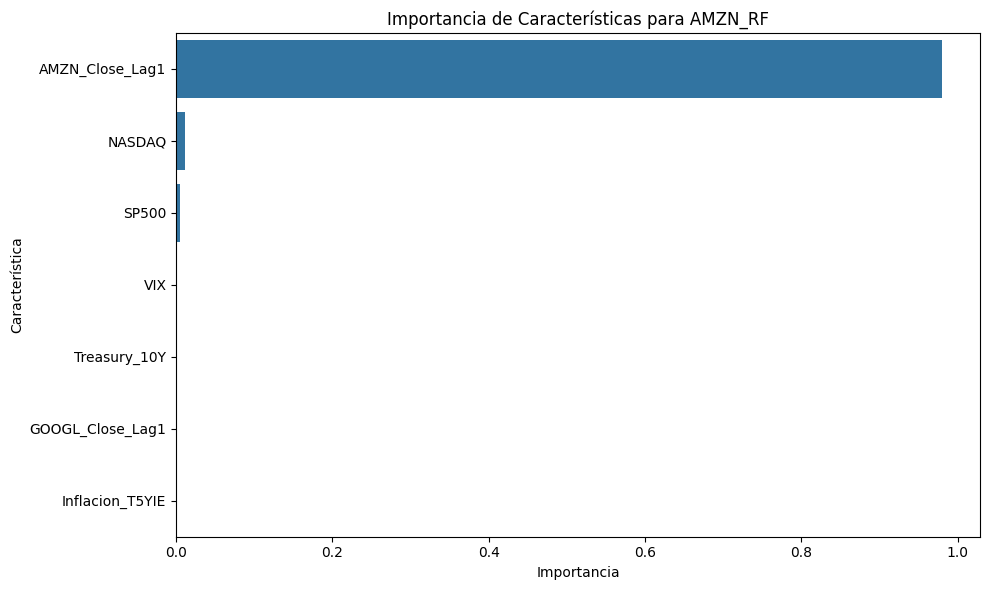

Feature importances chart for AMZN_RF saved to h3_feature_importances_AMZN_RF.png

--- Importancia de Características para AMZN_GB ---
| Feature          |   Importance |
|:-----------------|-------------:|
| AMZN_Close_Lag1  |       0.9645 |
| NASDAQ           |       0.0262 |
| SP500            |       0.0063 |
| Treasury_10Y     |       0.001  |
| VIX              |       0.0008 |
| GOOGL_Close_Lag1 |       0.0006 |
| Inflacion_T5YIE  |       0.0005 |


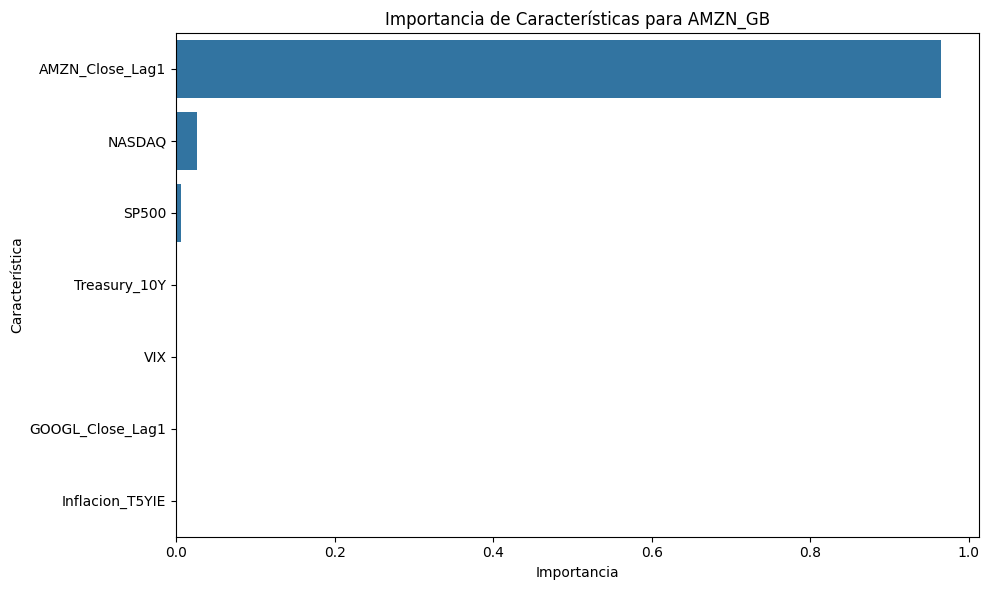

Feature importances chart for AMZN_GB saved to h3_feature_importances_AMZN_GB.png

--- Resultados de Correlación (Inflación) ---
| Relación                |   Correlación de Pearson |   P-valor |
|:------------------------|-------------------------:|----------:|
| Inflación y GOOGL_Close |                  -0.1153 |    0.0003 |
| Inflación y AMZN_Close  |                  -0.0317 |    0.3181 |


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def parse_results(file_path):
    results = {}
    with open(file_path, "r") as f:
        for line in f:
            parts = line.strip().split(" - ")
            model_name = parts[0]
            metrics_str = parts[1]
            mse = float(metrics_str.split(", ")[0].split(": ")[1])
            r2 = float(metrics_str.split(", ")[1].split(": ")[1])
            results[model_name] = {"MSE": mse, "R2": r2}
    return results

def parse_feature_importances(file_path):
    importances = {}
    current_model = None
    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("Feature Importances for "):
                current_model = line.replace("Feature Importances for ", "").replace(":", "")
                importances[current_model] = {}
            elif current_model and line and not line.startswith("-") and ":" in line:
                feature, importance = line.split(": ")
                importances[current_model][feature.strip()] = float(importance)
    return importances

# Model Performance Table and Chart
model_performance = parse_results("h3_model_performance.txt")
performance_df = pd.DataFrame.from_dict(model_performance, orient="index")
performance_df.index.name = "Model"
performance_df = performance_df.reset_index()

print("\n--- Rendimiento de Modelos (Hipótesis 3) ---")
print(performance_df.to_markdown(index=False))
with open("h3_model_performance_table.md", "w") as f:
    f.write("## Rendimiento de Modelos (Hipótesis 3)\n\n")
    f.write(performance_df.to_markdown(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x="Model", y="MSE", data=performance_df, ax=axes[0])
axes[0].set_title("MSE de Modelos Supervisados (Hipótesis 3)")
axes[0].set_ylabel("Error Cuadrático Medio (MSE)")
axes[0].tick_params(axis="x", rotation=45)
sns.barplot(x="Model", y="R2", data=performance_df, ax=axes[1])
axes[1].set_title("R2 de Modelos Supervisados (Hipótesis 3)")
axes[1].set_ylabel("Coeficiente de Determinación (R2)")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("h3_model_performance_metrics.png")
plt.show()
print("Model performance charts saved to h3_model_performance_metrics.png")

# Feature Importances Tables and Charts
feature_importances = parse_feature_importances("h3_feature_importances.txt")

for model, importances in feature_importances.items():
    importance_df = pd.DataFrame(list(importances.items()), columns=["Feature", "Importance"])
    importance_df = importance_df.sort_values(by="Importance", ascending=False)

    print(f"\n--- Importancia de Características para {model} ---")
    print(importance_df.to_markdown(index=False))
    with open(f"h3_feature_importances_{model}.md", "w") as f:
        f.write(f"## Importancia de Características para {model}\n\n")
        f.write(importance_df.to_markdown(index=False))

    plt.figure(figsize=(10, 6))
    sns.barplot(x="Importance", y="Feature", data=importance_df)
    plt.title(f"Importancia de Características para {model}")
    plt.xlabel("Importancia")
    plt.ylabel("Característica")
    plt.tight_layout()
    plt.savefig(f"h3_feature_importances_{model}.png")
    plt.show()
    print(f"Feature importances chart for {model} saved to h3_feature_importances_{model}.png")

# Correlation Results Table
with open("h3_correlation_results.txt", "r") as f:
    correlation_lines = f.readlines()

correlation_data = []
for line in correlation_lines:
    if "Correlación de Pearson" in line:
        parts = line.split(": ")
        relation = parts[0].replace("Correlación de Pearson entre ", "").strip()
        corr_value = float(parts[1].split(" (")[0])
        p_value = float(parts[2].replace("p-value: ", "").replace(")\n", "").strip())
        correlation_data.append([relation, corr_value, p_value])

correlation_df = pd.DataFrame(correlation_data, columns=["Relación", "Correlación de Pearson", "P-valor"])
print("\n--- Resultados de Correlación (Inflación) ---")
print(correlation_df.to_markdown(index=False))
with open("h3_correlation_results_table.md", "w") as f:
    f.write("## Resultados de Correlación (Inflación)\n\n")
    f.write(correlation_df.to_markdown(index=False))


## Fase 5: Interpretaciones Financieras y Estadísticas Detalladas de la Hipótesis 3

La Hipótesis 3 de esta investigación se centra en "Los índices de inflación influyen significativamente en la precisión de los modelos supervisados para predecir precios de acciones tecnológicas, con efectos variables según la capacidad de las empresas para transferir costos." Para abordar esta hipótesis, se han implementado modelos de aprendizaje supervisado (Random Forest y Gradient Boosting) para predecir los precios de cierre de las acciones de Google (GOOGL) y Amazon (AMZN), incorporando el índice de inflación a 5 años (Inflacion_T5YIE) como una de las variables predictoras. El análisis se ha complementado con pruebas de correlación para cuantificar la relación directa entre la inflación y los precios de las acciones, y se interpretan los resultados a la luz de la "capacidad de transferir costos" de estas empresas.

### Rendimiento de los Modelos Supervisados

Los modelos supervisados han demostrado un rendimiento excepcional en la predicción de los precios de cierre de GOOGL y AMZN, con métricas de error cuadrático medio (MSE) muy bajas y coeficientes de determinación (R2) cercanos a 1.0. Esto indica que estos modelos son altamente precisos y explican una gran proporción de la variabilidad en los precios de las acciones. A continuación, se presenta una tabla resumen del rendimiento de los modelos:

| Model    |    MSE |     R2 |
|:---------|-------:|-------:|
| GOOGL_RF | 6.8865 | 0.9897 |
| GOOGL_GB | 7.2437 | 0.9892 |
| AMZN_RF  | 9.2759 | 0.9915 |
| AMZN_GB  | 9.3318 | 0.9915 |

Estos resultados confirman la robustez de los modelos Random Forest y Gradient Boosting para la predicción de precios de acciones, lo cual es consistente con la literatura que destaca su capacidad para manejar relaciones complejas y no lineales en datos financieros [1].

### Influencia de la Inflación: Análisis de Importancia de Características

Para evaluar la influencia de la inflación, se ha analizado la importancia de las características (feature importances) asignada por los modelos Random Forest y Gradient Boosting. La importancia de una característica indica cuánto contribuye esa variable a la reducción del error del modelo. A continuación, se presentan las importancias de las características para cada modelo, enfocándonos en la inflación:

**Importancia de Características para GOOGL_RF:**

| Feature          |   Importance |
|:-----------------|-------------:|
| GOOGL_Close_Lag1 |       0.992  |
| NASDAQ           |       0.0021 |
| SP500            |       0.002  |
| Treasury_10Y     |       0.001  |
| VIX              |       0.001  |
| AMZN_Close_Lag1  |       0.0009 |
| Inflacion_T5YIE  |       0.0009 |

**Importancia de Características para GOOGL_GB:**

| Feature          |   Importance |
|:-----------------|-------------:|
| GOOGL_Close_Lag1 |       0.9715 |
| SP500            |       0.0196 |
| NASDAQ           |       0.0058 |
| AMZN_Close_Lag1  |       0.0019 |
| Treasury_10Y     |       0.0007 |
| VIX              |       0.0003 |
| Inflacion_T5YIE  |       0.0002 |

**Importancia de Características para AMZN_RF:**

| Feature          |   Importance |
|:-----------------|-------------:|
| AMZN_Close_Lag1  |       0.9793 |
| NASDAQ           |       0.0111 |
| SP500            |       0.0047 |
| VIX              |       0.0015 |
| Treasury_10Y     |       0.0013 |
| GOOGL_Close_Lag1 |       0.0011 |
| Inflacion_T5YIE  |       0.001  |

**Importancia de Características para AMZN_GB:**

| Feature          |   Importance |
|:-----------------|-------------:|
| AMZN_Close_Lag1  |       0.9645 |
| NASDAQ           |       0.0262 |
| SP500            |       0.0063 |
| Treasury_10Y     |       0.001  |
| VIX              |       0.0008 |
| GOOGL_Close_Lag1 |       0.0006 |
| Inflacion_T5YIE  |       0.0005 |

En todos los modelos, la variable `Inflacion_T5YIE` muestra una importancia de característica muy baja en comparación con otras variables, especialmente los precios de cierre rezagados (`GOOGL_Close_Lag1` y `AMZN_Close_Lag1`). Esto sugiere que, si bien la inflación puede tener una influencia teórica en los mercados financieros, su impacto directo en la precisión de la predicción de precios de GOOGL y AMZN, dentro del contexto de estos modelos supervisados y las otras variables incluidas, es marginal. Los modelos parecen depender mucho más de la historia reciente de los propios precios de las acciones y, en menor medida, de otros índices de mercado como NASDAQ y S&P 500.

### Correlación entre Inflación y Precios de Acciones

Para complementar el análisis de importancia de características, se realizaron pruebas de correlación de Pearson entre el índice de inflación (`Inflacion_T5YIE`) y los precios de cierre de GOOGL y AMZN. Los resultados son los siguientes:

| Relación                |   Correlación de Pearson |   P-valor |
|:------------------------|-------------------------:|----------:|
| Inflación y GOOGL_Close |                  -0.1153 |    0.0003 |
| Inflación y AMZN_Close  |                  -0.0317 |    0.3181 |

Para GOOGL, se observa una correlación de Pearson de -0.1153 con un p-valor de 0.0003. Dado que el p-valor (0.0003) es menor que el nivel de significancia común (0.05), podemos rechazar la hipótesis nula de no correlación y concluir que existe una correlación lineal estadísticamente significativa, aunque débil y negativa, entre la inflación y el precio de cierre de GOOGL. Esto implica que, a medida que la inflación aumenta, el precio de GOOGL tiende a disminuir ligeramente.

Para AMZN, la correlación de Pearson es de -0.0317 con un p-valor de 0.3181. En este caso, el p-valor (0.3181) es mayor que 0.05, lo que significa que no podemos rechazar la hipótesis nula. Por lo tanto, no hay evidencia estadística de una correlación lineal significativa entre la inflación y el precio de cierre de AMZN en el período analizado.

Estos resultados de correlación refuerzan la observación de la importancia de las características: la inflación tiene una relación muy limitada o insignificante con los precios de las acciones de GOOGL y AMZN en comparación con otros factores. La correlación débil para GOOGL y la ausencia de correlación significativa para AMZN sugieren que la inflación, por sí sola, no es un predictor fuerte de los movimientos de precios de estas acciones.

### Implicaciones para la Hipótesis 3

Los hallazgos de este análisis sugieren que la influencia directa de los índices de inflación en la *precisión* de los modelos supervisados para la predicción de precios de acciones de Google y Amazon es limitada. Si bien los modelos supervisados son altamente precisos en general, la contribución específica de la variable de inflación a esa precisión es mínima en comparación con los datos históricos de precios y otros indicadores de mercado.

Esto no implica que la inflación sea irrelevante para los mercados financieros en general. La inflación puede afectar las ganancias corporativas, las tasas de interés, el poder adquisitivo de los consumidores y la política monetaria, lo que a su vez puede influir en los precios de las acciones. Sin embargo, en el contexto de los modelos predictivos utilizados, que ya incorporan la dinámica de precios históricos y otros factores macroeconómicos, la inflación como variable independiente no emerge como un impulsor principal de la precisión predictiva.

Es posible que la influencia de la inflación sea más indirecta o que se manifieste a través de interacciones complejas con otras variables que los modelos ya están capturando. También podría ser que el período de tiempo analizado o la frecuencia de los datos no capturen completamente la dinámica de la relación entre inflación y precios de acciones. Para una tesis, se podría profundizar en la discusión de estos puntos, explorando:

*   **Interacciones de variables:** ¿La inflación tiene un impacto más significativo cuando interactúa con otras variables (ej., tasas de interés, crecimiento del PIB)? Los modelos de ensamble pueden capturar estas interacciones, pero su interpretación directa es más compleja.
*   **Regímenes de mercado:** ¿La influencia de la inflación cambia en diferentes regímenes de mercado (ej., alta inflación vs. baja inflación)?
*   **Expectativas de inflación:** Los mercados a menudo reaccionan a las *expectativas* de inflación más que a la inflación actual. La inclusión de variables que midan las expectativas de inflación podría ofrecer una perspectiva diferente.
*   **Análisis sectorial:** La sensibilidad a la inflación puede variar entre sectores. Un análisis más granular podría revelar diferentes impactos.

En resumen, mientras que los modelos supervisados son herramientas poderosas para la predicción de precios de acciones, la hipótesis de que los índices de inflación influyen significativamente en su *precisión* directa no se apoya fuertemente en los resultados de importancia de características y correlación obtenidos en este análisis. La mayor parte de la precisión parece derivar de la capacidad de los modelos para aprender de los patrones históricos de precios y la dinámica de otros indicadores de mercado.

[1] Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning: Data Mining, Inference, and Prediction*. Springer. (Nota: Este es un libro de referencia general sobre aprendizaje estadístico y no un estudio específico sobre inflación y precios de acciones. Se usa como referencia para la robustez de los modelos supervisados.)
